<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Description**

You have been provided with a data set containing daly sales and profit data of the company for the periode 2011 to 2014. the data set has
the following there attributes.




**Attributes	          Description**

**Order-Date**	     The date on which the order was placed (in dd-mm-yyyy format)

**Sales	Total**      sales value of the transaction (in dollars)

**Profit**	         Profit made on the transaction (in dollars)

***Outline***

In the demonstration, we will:

  .Prepare the data for time series modeling

  .forecasting sales using the following models:

    *Autoregressive(AR)

    *Autoregressive integrated
    moving average(ARIMA)

    *Seasonal autoregressive integrated moving average(SARIMA)

  We will analyze the performance of these models using root of the forcasting models using any one of RMSE or MAPE to obtain a more comprehensive assessment of their performance we will use both measures for each models.

**Part 1-Setup and Dta Preparation**

In this section,we will:

  * Import necessary packages for executing the code
  
  *Load the data

  *Prepare the data for futher analysis

  

In [2]:
# Import 'numpy ' and pandas for working with numbers and dataframe
import numpy as np
import pandas as pd

#IMport "pyplot" from matplotlib and seaborn from visualization

from matplotlib import pyplot as plt
import seaborn as sns

# Import and execute methods for suppressing warnings

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

Let's begin by loading the data and building familiarity with it.

In [3]:
data = pd.read_csv('Superstore_Data.csv')

In [4]:
data

,Order Date,Sales,Profit
0,17-10-2013,5175.1710,919.9710
1,07-11-2011,1822.0800,564.8400
2,14-04-2012,5244.8400,996.4800
3,06-06-2013,3701.5200,1036.0800
4,25-02-2012,1878.7200,582.3600
...,...,...,...
5694,14-01-2013,38.9709,-32.3991
5695,12-11-2014,6.9000,-0.8400
5696,03-11-2011,17.2800,-13.9200
5697,26-07-2013,30.6180,1.0080


In [5]:
data.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [6]:
data.dtypes

,0
Order Date,object
Sales,float64
Profit,float64


As you can see that data type of the order Date columns is object.but to further conduct analyses on the data,such as grouping by month or year we have to convert the data type of the order date columns to datetime.

In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

/tmp/ipykernel_2116/3021409918.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Order Date'] = pd.to_datetime(data['Order Date'])


In [8]:
data.dtypes

,0
Order Date,datetime64[ns]
Sales,float64
Profit,float64


Let's make sure that the data points in the data frame are ordered by date.

In [9]:
data.sort_values('Order Date',ascending=True,ignore_index =True,inplace=True)

In [10]:
data.head()

,Order Date,Sales,Profit
0,2011-01-01,55.242,15.342
1,2011-01-01,120.366,36.036
2,2011-01-01,113.670,37.770
3,2011-01-03,912.456,-319.464
4,2011-01-03,6.006,0.546


Next we will set the update Order Date fuature as the index of the data Frame.

In [11]:
data.set_index('Order Date', inplace=True)

In [12]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [13]:
data.iloc[2:5]

,Sales,Profit
Order Date,,
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [14]:
data.loc['2011-01-01':'2011-03-01']

,Sales,Profit
Order Date,,
2011-01-01,55.2420,15.3420
2011-01-01,120.3660,36.0360
2011-01-01,113.6700,37.7700
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
...,...,...
2011-03-01,91.8720,-45.9480
2011-03-01,12.6360,-1.1640
2011-03-01,238.9290,62.1690


**Note**: When we change the index of the data, then to select the row using new index we should this methods df.loc["new_index"]


To study monthely sales, we need to group the row of df by monthely and sum up the value in each group.We will use the Grouper function in conjunction with the groupby operator for grouping.Grouper is a function in the pandas liberary that allow us to grouping time series data
based on a specification frequency (frq) which in our case is monthaly(M).

In [15]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [16]:
data = data.groupby(pd.Grouper(freq = 'M')).sum()

/tmp/ipykernel_2116/1357590196.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.groupby(pd.Grouper(freq = 'M')).sum()


In [17]:
data.shape

(48, 2)

You can see that onaly data from each month is used in the index as representative of each of those months.

Recall from the problem statement that we are interested in forecasting Sales. So we can drop the profit feature from our data sets.

In [18]:
data.head()

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423


In [19]:
data.drop(columns='Profit', inplace=True)

In [20]:
data.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


Let's now plot our data set to visualize our time series and try to identiy patterns in it..

<Axes: xlabel='Order Date'>

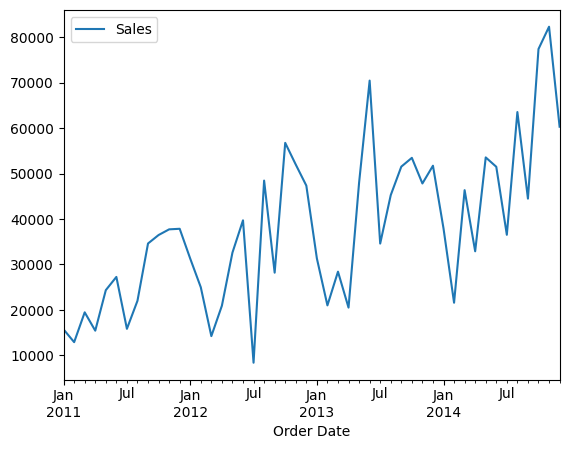

In [21]:
data.plot()

**Now We have 4 main properties in the time series data**

1.Trend:Upward or downward

2.Seasonality: A repeating pattern at a constant time interval.

3.Cyclic nature: A repeating pattern at random time intervals.

4.Noise: Somthing random, you can't explain.

**Part 2 - Stationary Analysis**

in this part of the demonstration, we will perform tests on the time series data to understand it is statonary or not. the autoregressive modeling requires the time series data to be statonary. To test this, we will use the following test:

   .Augmented Dickey-Fuller(ADF) Test

***ADF Test***

In [22]:
from statsmodels.tsa.stattools import adfuller

In [23]:
result = adfuller(data['Sales'])

**Note that the null hypothesis for the ADF Testing is The time series is not stationary**

In [24]:
result[1]

np.float64(0.1987628396941693)

***If p Value is<0.5, then our data is statonary otherwise our data is not-statonary


We have analyzed our time series data.let's now split the data into traning and testing set so that we're ready to build and evaluate time series model on the data.

In [25]:
data.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


In [27]:
df_train = data[0:42]
df_test = data[42:48]

<Axes: xlabel='Order Date', ylabel='Sales'>

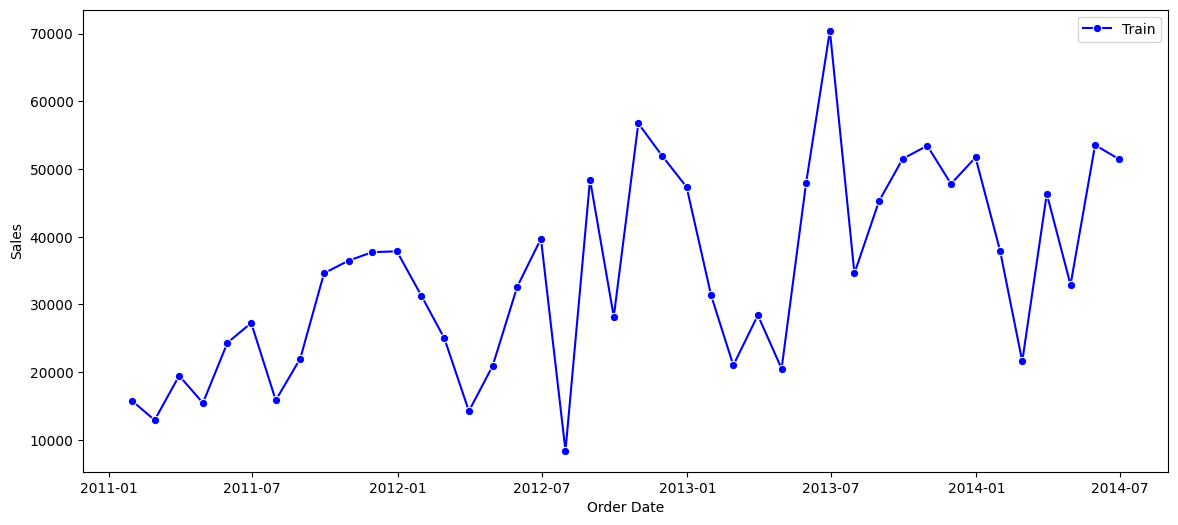

In [28]:
#plot the time seriesdata with the train-test split

plt.figure(figsize=(14,6))
sns.lineplot(data = df_train,x='Order Date', y='Sales',marker = 'o',color='blue',label='Train')